# Revised Ground Truth 
- I have also decided a more principled way of doing the model comparison would be to fit Fourier modes to the data and use an MCMC to extract the uncertainties.
---
- Use the found priors as initial conditions.
- Randomise this.
- Opt with Fourier mode of 3 with MCMC.
- Define the samples with a weighted likelihood.
- Predict and extract posterios samples.


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import emcee

from scipy.optimize import minimize
from scipy.special import softmax

import celerite2
from celerite2 import terms

from prettytable import PrettyTable

from scipy.stats import norm

import sys
from pathlib import Path
from IPython.display import display as ipy_display

sys.path.append(str(Path('../..').resolve()))

from helpers.df_ops import prepare_df, split_df, clean_df
from helpers.priors import find_classify_signals, get_priors

def downsample_min_gap(df, minimum_gap):
    days = df["day"].values
    keep = np.zeros(len(days), dtype=bool)
    keep[0] = True
    last_kept = days[0]
    for i in range(1, len(days)):
        if days[i] - last_kept >= minimum_gap:
            keep[i] = True
            last_kept = days[i]
    return df[keep].reset_index(drop=True)



In [28]:
# ---- PARAMS ----
datapath            = r"../../Data/benchmark/HD81809_Mt_wilson_data.txt"
direct_bound_tol    = 0.1
sm2016_bound_tol    = 0.2
mean_bound_tol      = 1
add_prefix          = False
relative            = True
train_split         = 0.6
valid_split         = 0.15 
star_type           = "G"
star_name           = "HD201091"
error_percent       = 2.5
sigma_upper_mult    = 5.0
q_bounds_in         = [1, 5]  # THIS HAS BEEN CHANGED
verbose             = True
plot                = True
loop_verbose        = True
loop_plot           = True
loop_savefigs       = False
sampler_plot        = True
result_plot_cadence = 50
result_plot_extra   = 1000
require_mid         = True
total_sample_count  = 2500
plot_every          = 200
subsample           = 500
n_walkers           = 32
valid_metric        = "CRPS"
SEED                = 1701


verbose_clean = False
plot_clean = False
plot_fitpeaks = False
verbose_fitpeaks = False
plot_genpriors = False
verbose_genpriors = False
plot_comparison = False
verbose_comparison = False
verbose_selected = True
plot_sampler = False


pred_forward_years = 2

low_cad = 30
high_cad = 10

min_gap = 3

In [29]:
raw_df  = pd.read_csv(datapath, sep=r'\s+', skip_blank_lines=True)
raw_data_df  = prepare_df(raw_df, add_prefix=False, relative=True)

# Downsample
data_df = downsample_min_gap(raw_data_df, min_gap)

#Split
dirty_train_df, dirty_valid_df, test_df = split_df(data_df, train_split=train_split, valid_split=valid_split)

# Clean
train_df, valid_df, MAD = clean_df(dirty_train_df, dirty_valid_df, tol=4, verbose=verbose_clean, plot=plot_clean)

In [30]:
raw_std = np.std(raw_data_df['sind'])

log_AB_bounds = np.log([[1e-4, 5*raw_std] for _ in range(6)])  # (6,2) 
log_T_bounds  = np.log([[1e-4, raw_data_df['day'].iloc[-1] - raw_data_df['day'].iloc[0]]])  # (1,2)
c_bounds = [[raw_data_df['sind'].min(), raw_data_df['sind'].max()]]  # (1,2)

bounds = np.concatenate([log_AB_bounds, log_T_bounds, c_bounds])


def lnPost_Fourier(params, t, y, sigma, weights, bounds):
    '''
    Based on a 3 mode fitting with A1, A2, A3, B1, B2, B3, T, and c
    params[-1] is c in linear space, rest are log space.
    t, y, sigma, weights are precomputed numpy arrays.
    sigma is per-point (shape N).
    '''
    if np.any(params < bounds[:, 0]) or np.any(params > bounds[:, 1]):
        return -np.inf

    A1, A2, A3 = np.exp(params[0:3])
    B1, B2, B3 = np.exp(params[3:6])
    T = np.exp(params[6])
    c = params[7]

    model  = c + A1*np.sin(2*np.pi*t/T) + B1*np.cos(2*np.pi*t/T)
    model += A2*np.sin(4*np.pi*t/T)     + B2*np.cos(4*np.pi*t/T)
    model += A3*np.sin(6*np.pi*t/T)     + B3*np.cos(6*np.pi*t/T)

    lnL = np.sum(weights * (-np.log(sigma) - 0.5*np.log(2*np.pi) - 0.5*((y - model)/sigma)**2))
    return lnL

In [31]:
#---LSP--- the mid prior is used as tau and for the initial guess of T
classified_signal_data = find_classify_signals(raw_data_df,
                                            plot_fitpeaks=plot_fitpeaks, verbose_fitpeaks=verbose_fitpeaks,
                                            plot_genpriors=plot_genpriors, verbose_genpriors=verbose_genpriors)

rho_priors, rho_prior_bounds, rho_sources = get_priors(classified_signal_data,
                                                    star_type=star_type,
                                                    direct_bound_tol=direct_bound_tol,
                                                    sm2016_bound_tol=sm2016_bound_tol,
                                                    mean_bound_tol=mean_bound_tol,
                                                    verbose=verbose)

KeyboardInterrupt: 

In [ ]:
raw_initial_guess_AB = [(raw_data_df['sind'].max() - raw_data_df['sind'].min()) / 6 for _ in range(6)]
raw_initial_guess_T = [rho_priors['mid']]
initial_guess_c = [np.median(raw_data_df['sind'])]

initial_guesses = np.concatenate([np.log(raw_initial_guess_AB), np.log(raw_initial_guess_T), initial_guess_c])

walker_start_coords = initial_guesses + 1e-4 * np.random.randn(n_walkers, len(initial_guesses))

tau = rho_priors['mid']
t0_day = test_df['day'].iloc[0]

# Precompute arrays passed to lnPost_Fourier
t_arr   = raw_data_df['day'].to_numpy()
y_arr   = raw_data_df['sind'].to_numpy()
sigma   = y_arr * error_percent / 100
weights = np.where(t_arr < t0_day, np.exp(-(t0_day - t_arr) / tau), 1.0)

sampler = emcee.EnsembleSampler(n_walkers, len(initial_guesses), lnPost_Fourier,
                args=(t_arr, y_arr, sigma, weights, bounds))
sampler.run_mcmc(walker_start_coords, nsteps=total_sample_count, progress=True)

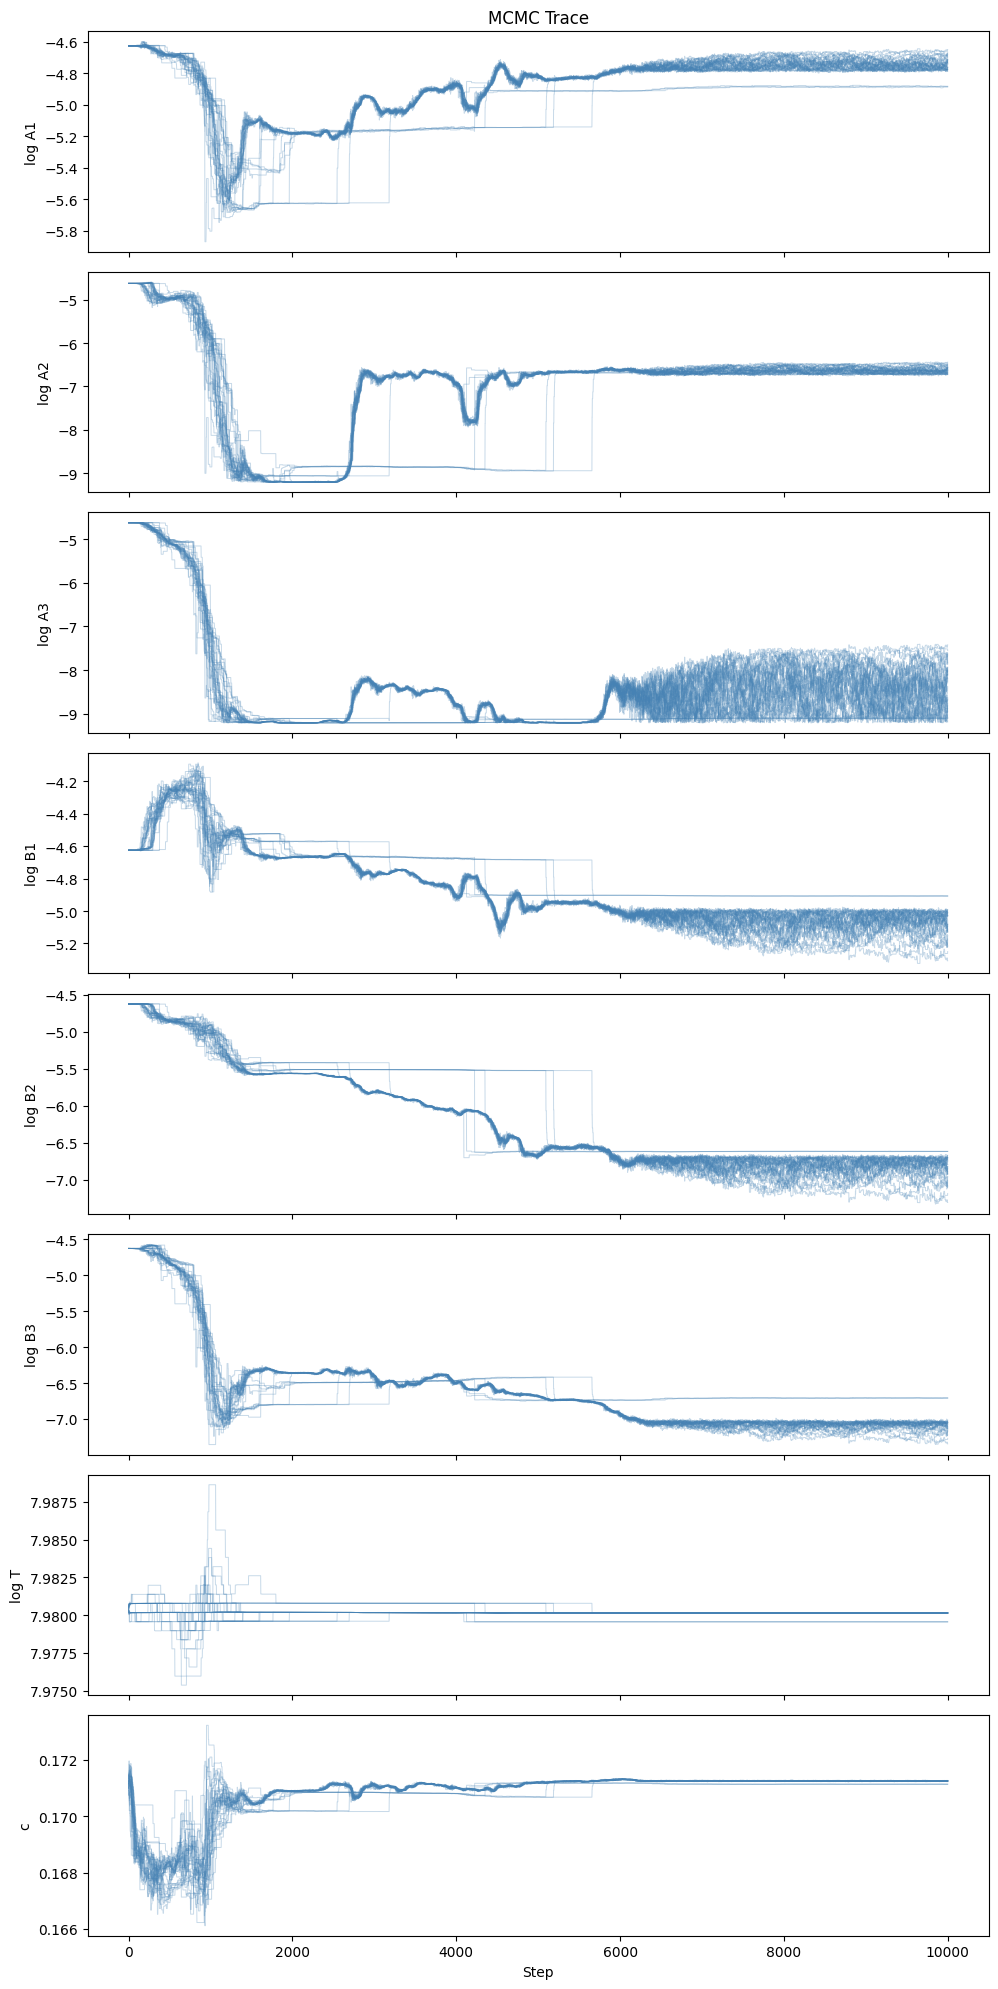

In [ ]:
# Create trace plot 
param_names = ['log A1', 'log A2', 'log A3', 'log B1', 'log B2', 'log B3', 'log T', 'c']

samples = sampler.get_chain()  # shape: (n_steps, n_walkers, n_params)
n_steps, n_walkers, n_params = samples.shape

fig, axes = plt.subplots(n_params, 1, figsize=(10, 2.5 * n_params), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(samples[:, :, i], color='steelblue', alpha=0.3, lw=0.7)
    ax.set_ylabel(param_names[i])
axes[-1].set_xlabel('Step')
axes[0].set_title('MCMC Trace')
plt.tight_layout()
plt.show()


In [ ]:
# Remove the burn in
chains = sampler.get_chain(discard=5000)  # shape: (n_steps - 5000, n_walkers, n_params)
flat_samples = sampler.get_chain(discard=5000, flat=True)  # shape: (n_remaining * n_walkers, n_params)

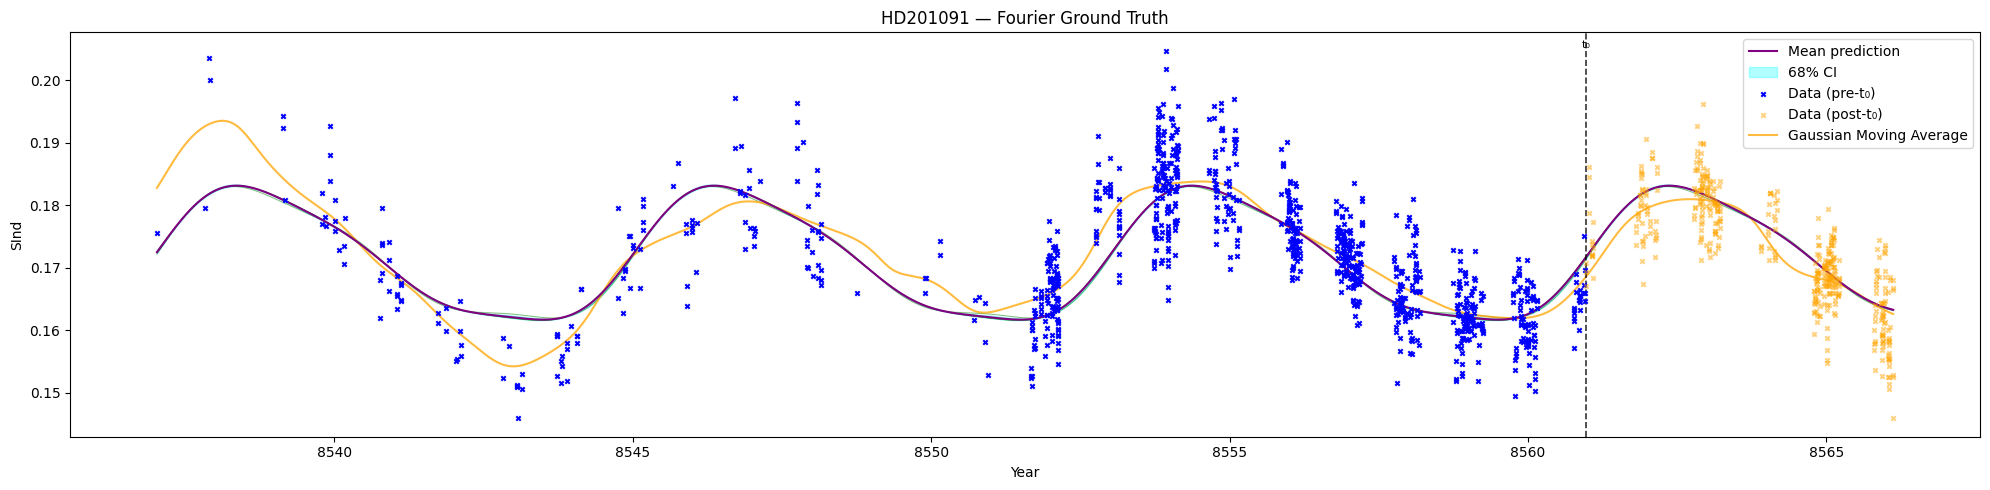

In [ ]:
# Reference for year conversion
t0_ref_day  = raw_data_df['day'].iloc[0]
t0_ref_year = raw_data_df['year'].iloc[0]

def to_year(day):
    return t0_ref_year + (day - t0_ref_day) / 365.25

def gaussian_smooth(t, y, sigma, n_eval=1000):
    t_eval = np.linspace(t.min(), t.max(), n_eval)
    w = np.exp(-0.5 * ((t[:, None] - t_eval[None, :]) / sigma) ** 2)
    return t_eval, (w * y[:, None]).sum(axis=0) / w.sum(axis=0)

# Dense time grid over full data span
t_plot      = np.linspace(raw_data_df['day'].min(), raw_data_df['day'].max(), 2000)
t_plot_year = to_year(t_plot)
t0_pred_year = to_year(t0_day)

# Evaluate model for each posterior sample
step = max(1, len(flat_samples) // subsample)
model_preds = []
for s in flat_samples[::step]:
    A1, A2, A3 = np.exp(s[0:3])
    B1, B2, B3 = np.exp(s[3:6])
    T = np.exp(s[6])
    c = s[7]
    m  = c + A1*np.sin(2*np.pi*t_plot/T) + B1*np.cos(2*np.pi*t_plot/T)
    m += A2*np.sin(4*np.pi*t_plot/T)     + B2*np.cos(4*np.pi*t_plot/T)
    m += A3*np.sin(6*np.pi*t_plot/T)     + B3*np.cos(6*np.pi*t_plot/T)
    model_preds.append(m)

model_preds = np.array(model_preds)
mean_pred   = model_preds.mean(axis=0)
lb          = np.percentile(model_preds, 16, axis=0)
ub          = np.percentile(model_preds, 84, axis=0)

# Gaussian smooth of actual data
t_smooth, y_smooth = gaussian_smooth(raw_data_df['day'].values, raw_data_df['sind'].values, sigma=182.5)
t_smooth_year = to_year(t_smooth)

# Split data at t0 for colouring
train_mask = raw_data_df['day'] < t0_day
test_mask  = ~train_mask

fig, ax = plt.subplots(figsize=(20, 5))

for i, pred in enumerate(model_preds):
    if i % plot_every == 0:
        ax.plot(t_plot_year, pred, color='green', alpha=0.5, lw=0.75)

ax.plot(t_plot_year, mean_pred, color='purple', label='Mean prediction', zorder=3)
ax.fill_between(t_plot_year, lb, ub, color='cyan', alpha=0.3, label='68% CI', zorder=1)

ax.scatter(raw_data_df['year'][train_mask], raw_data_df['sind'][train_mask],
            color='blue', s=10, marker='x', label='Data (pre-t₀)', zorder=4)
ax.scatter(raw_data_df['year'][test_mask], raw_data_df['sind'][test_mask],
            color='orange', s=10, marker='x', alpha=0.5, label='Data (post-t₀)', zorder=4)

ax.plot(t_smooth_year, y_smooth, color='orange', alpha=0.75, label='Gaussian Moving Average')

ax.axvline(t0_pred_year, color='black', linestyle='--', lw=1.2, alpha=0.8, zorder=3)
ax.text(t0_pred_year, 0.98, 't₀', transform=ax.get_xaxis_transform(), ha='center', va='top', fontsize=8)

ax.set_xlabel('Year')
ax.set_ylabel('SInd')
ax.set_title(f'{star_name} — Fourier Ground Truth')
ax.legend()
plt.tight_layout()
plt.show()

- This is much better.
- Now try it with worse data.

+------------+------------+-------------+----------------------+-----------------+--------+
| Cycle Type | Prior Days | Prior Years |     Bounds Days      |   Bounds Years  | Source |
+------------+------------+-------------+----------------------+-----------------+--------+
|   Short    |   37.33    |     0.10    |    (33.60, 41.06)    |   (0.09, 0.11)  | found  |
|    Mid     |  2923.04   |     8.01    |  (2630.74, 3215.35)  |   (7.21, 8.81)  | found  |
|    Long    |  36500.00  |    100.00   | (18250.00, 54750.00) | (50.00, 150.00) |  mean  |
+------------+------------+-------------+----------------------+-----------------+--------+


  0%|          | 0/25000 [00:00<?, ?it/s]c:\Users\Joey\Desktop\Cambridge\Work\Thesis\VenvThesis\lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 25000/25000 [00:35<00:00, 708.16it/s]


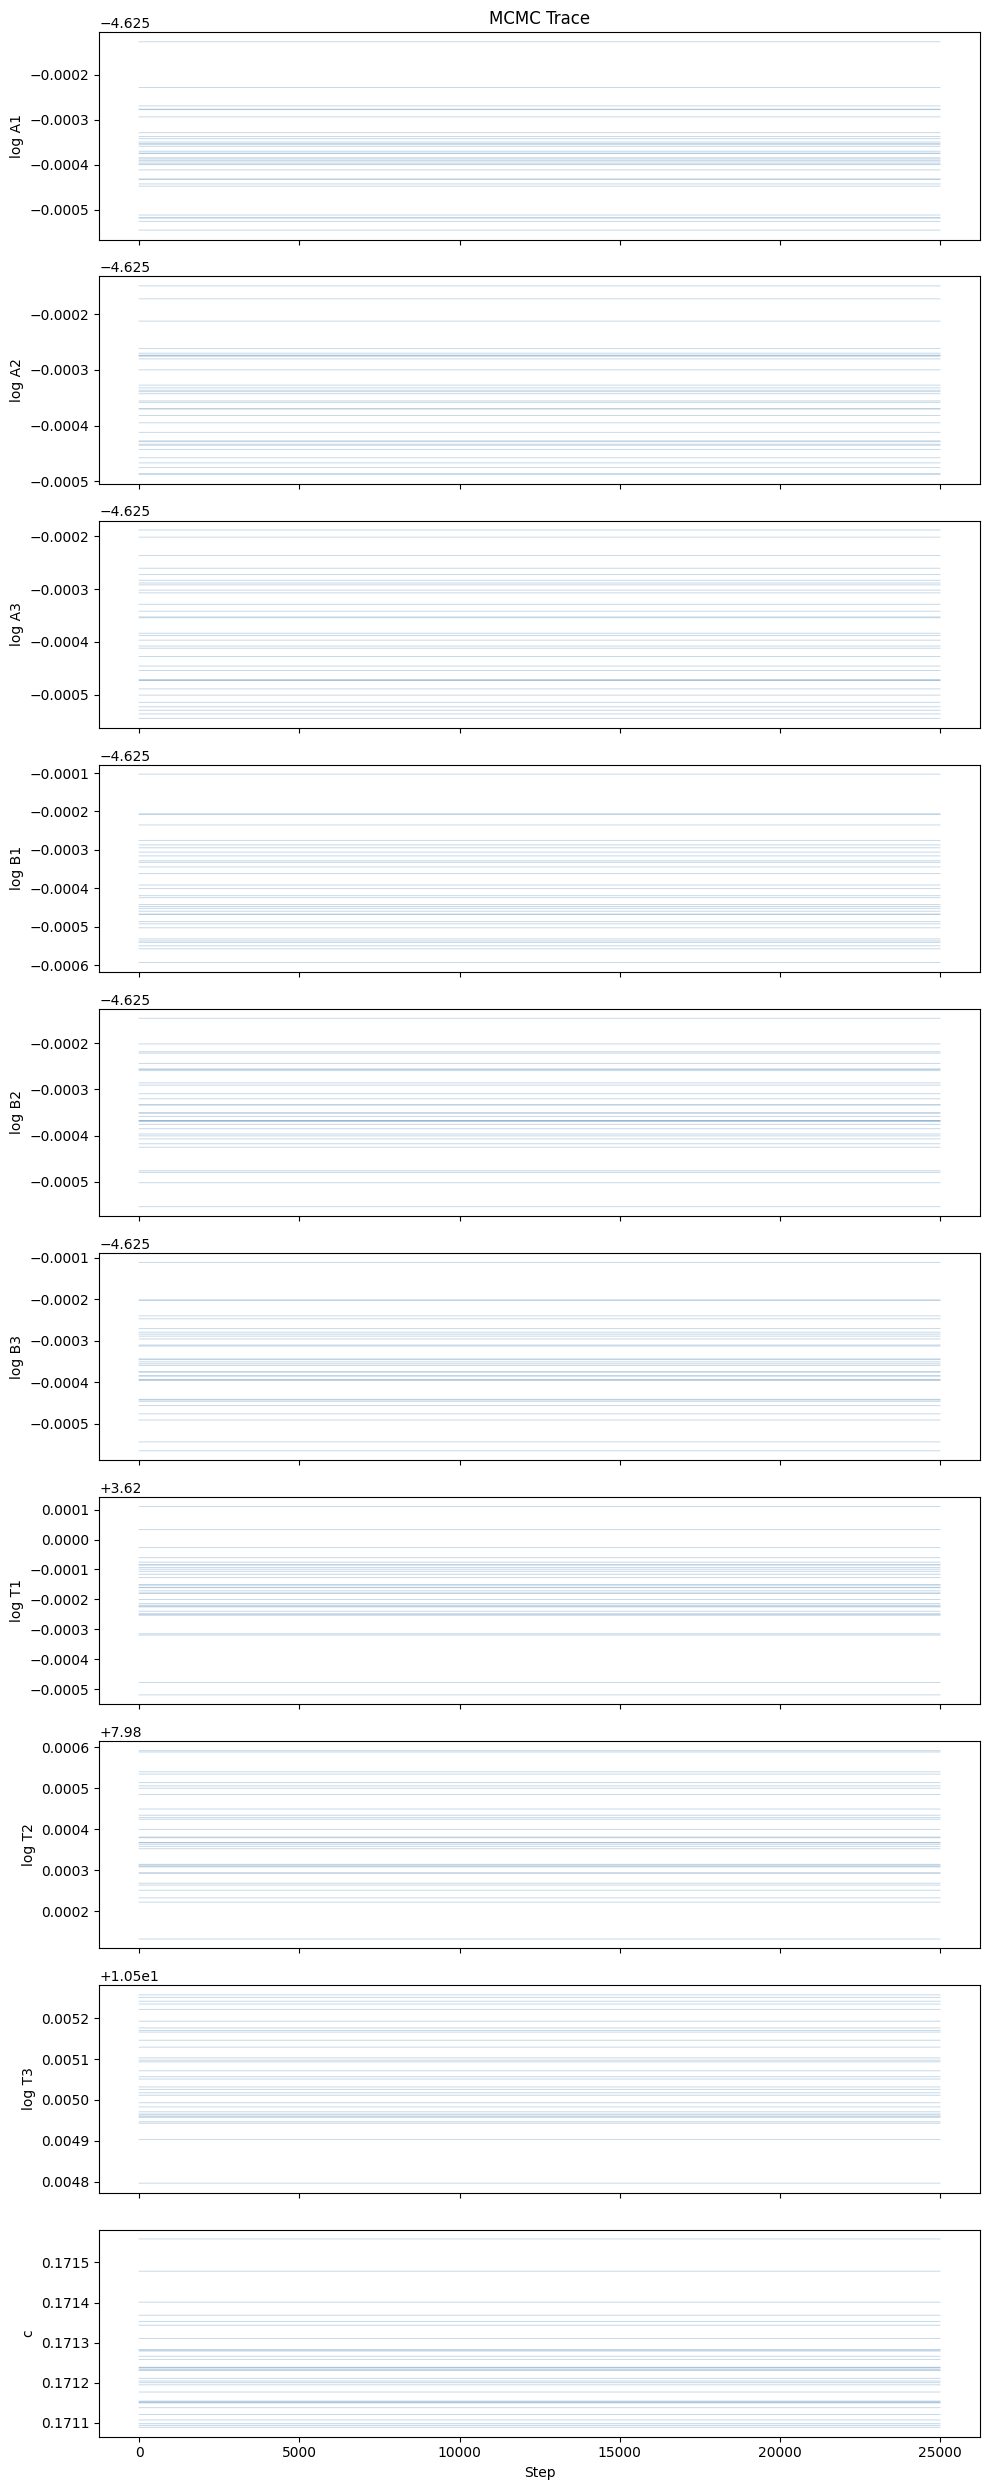

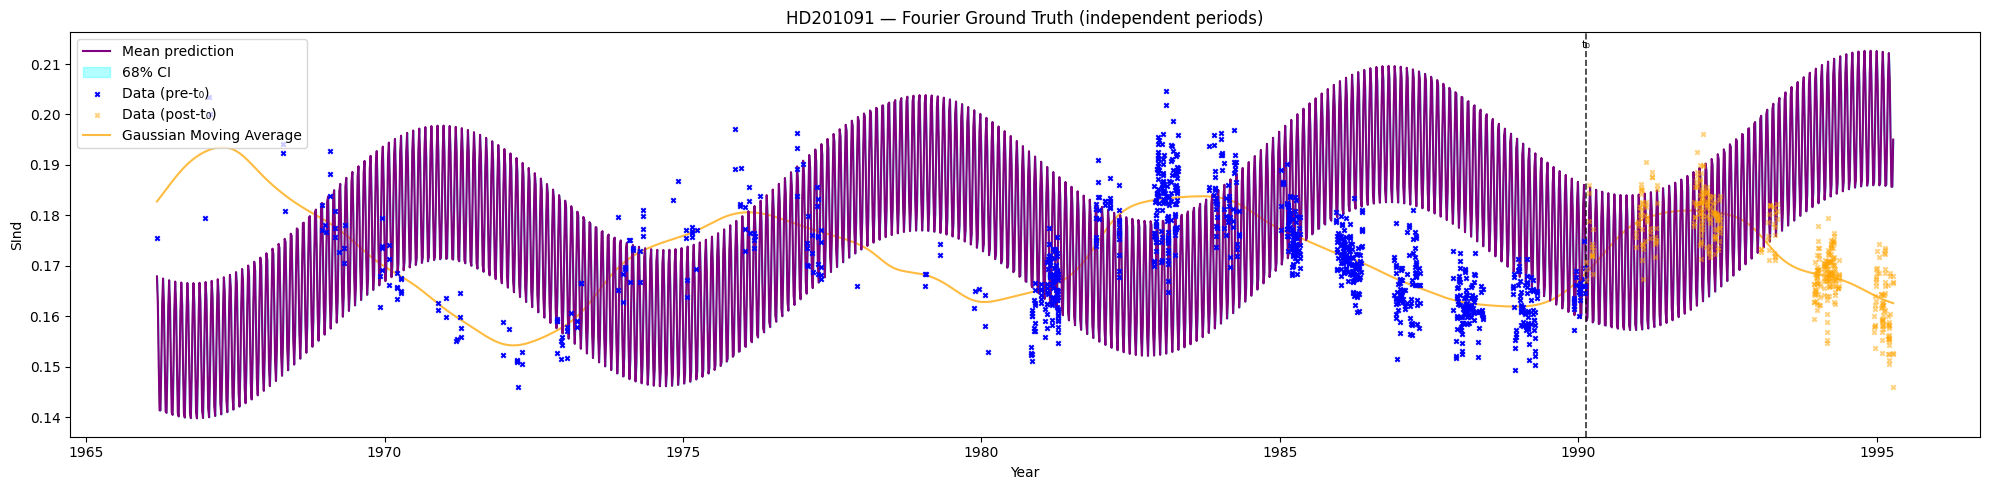

In [36]:
# ---- PARAMS ----
datapath            =r"../../Data/benchmark/HD81809_Mt_wilson_data.txt"
direct_bound_tol    = 0.1
sm2016_bound_tol    = 0.2
mean_bound_tol      = 1
add_prefix          = False
relative            = True
train_split         = 0.6
valid_split         = 0.15 
star_type           = "G"
star_name           = "HD201091"
error_percent       = 15
sigma_upper_mult    = 5.0
q_bounds_in         = [1, 5]
verbose             = True
plot                = True
loop_verbose        = True
loop_plot           = True
loop_savefigs       = False
sampler_plot        = True
result_plot_cadence = 50
result_plot_extra   = 1000
require_mid         = True
total_sample_count  = 25000
plot_every          = 200
subsample           = 500
n_walkers           = 32
valid_metric        = "CRPS"
SEED                = 1701

verbose_clean = False
plot_clean = False
plot_fitpeaks = False
verbose_fitpeaks = False
plot_genpriors = False
verbose_genpriors = False
plot_comparison = False
verbose_comparison = False
verbose_selected = True
plot_sampler = False

pred_forward_years = 2
low_cad = 30
high_cad = 10
min_gap = 3

raw_df  = pd.read_csv(datapath, sep=r'\s+', skip_blank_lines=True)
raw_data_df  = prepare_df(raw_df, add_prefix=False, relative=True)

data_df = downsample_min_gap(raw_data_df, min_gap)
dirty_train_df, dirty_valid_df, test_df = split_df(data_df, train_split=train_split, valid_split=valid_split)
train_df, valid_df, MAD = clean_df(dirty_train_df, dirty_valid_df, tol=4, verbose=verbose_clean, plot=plot_clean)

raw_std = np.std(raw_data_df['sind'])
span    = raw_data_df['day'].iloc[-1] - raw_data_df['day'].iloc[0]
log_AB_bounds = np.log([[1e-4, 5*raw_std] for _ in range(6)])
log_T_bounds  = np.log([[1e-4, span] for _ in range(3)])  # independent T1, T2, T3
c_bounds      = [[raw_data_df['sind'].min(), raw_data_df['sind'].max()]]
bounds        = np.concatenate([log_AB_bounds, log_T_bounds, c_bounds])  # (10, 2)


def lnPost_Fourier_multi(params, t, y, sigma, weights, bounds):
    '''
    3-mode Fourier with independent periods T1, T2, T3.
    params = [log_A1, log_A2, log_A3, log_B1, log_B2, log_B3, log_T1, log_T2, log_T3, c]
    '''
    if np.any(params < bounds[:, 0]) or np.any(params > bounds[:, 1]):
        return -np.inf

    A1, A2, A3 = np.exp(params[0:3])
    B1, B2, B3 = np.exp(params[3:6])
    T1, T2, T3 = np.exp(params[6:9])
    c           = params[9]

    model  = c + A1*np.sin(2*np.pi*t/T1) + B1*np.cos(2*np.pi*t/T1)
    model += A2*np.sin(2*np.pi*t/T2)     + B2*np.cos(2*np.pi*t/T2)
    model += A3*np.sin(2*np.pi*t/T3)     + B3*np.cos(2*np.pi*t/T3)

    lnL = np.sum(weights * (-np.log(sigma) - 0.5*np.log(2*np.pi) - 0.5*((y - model)/sigma)**2))
    return lnL


#---LSP---
classified_signal_data = find_classify_signals(raw_data_df,
                                            plot_fitpeaks=plot_fitpeaks, verbose_fitpeaks=verbose_fitpeaks,
                                            plot_genpriors=plot_genpriors, verbose_genpriors=verbose_genpriors)
rho_priors, rho_prior_bounds, rho_sources = get_priors(classified_signal_data,
                                                    star_type=star_type,
                                                    direct_bound_tol=direct_bound_tol,
                                                    sm2016_bound_tol=sm2016_bound_tol,
                                                    mean_bound_tol=mean_bound_tol,
                                                    verbose=verbose)

amp_guess = (raw_data_df['sind'].max() - raw_data_df['sind'].min()) / 6
initial_guesses = np.array([
    np.log(amp_guess), np.log(amp_guess), np.log(amp_guess),   # log A1, A2, A3
    np.log(amp_guess), np.log(amp_guess), np.log(amp_guess),   # log B1, B2, B3
    np.log(rho_priors['short']),                                # log T1
    np.log(rho_priors['mid']),                                  # log T2
    np.log(rho_priors['long']),                                 # log T3
    np.median(raw_data_df['sind']),                             # c
])

walker_start_coords = initial_guesses + 1e-4 * np.random.randn(n_walkers, len(initial_guesses))

tau   = rho_priors['mid']
t0_day = test_df['day'].iloc[0]

t_arr   = raw_data_df['day'].to_numpy()
y_arr   = raw_data_df['sind'].to_numpy()
sigma   = y_arr * error_percent / 100
weights = np.where(t_arr < t0_day, np.exp(-(t0_day - t_arr) / tau), 1.0)

sampler = emcee.EnsembleSampler(n_walkers, len(initial_guesses), lnPost_Fourier_multi,
                args=(t_arr, y_arr, sigma, weights, bounds))
sampler.run_mcmc(walker_start_coords, nsteps=total_sample_count, progress=True)

param_names = ['log A1', 'log A2', 'log A3', 'log B1', 'log B2', 'log B3', 'log T1', 'log T2', 'log T3', 'c']
samples = sampler.get_chain()
n_steps, n_walkers, n_params = samples.shape
fig, axes = plt.subplots(n_params, 1, figsize=(10, 2.5 * n_params), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(samples[:, :, i], color='steelblue', alpha=0.3, lw=0.7)
    ax.set_ylabel(param_names[i])
axes[-1].set_xlabel('Step')
axes[0].set_title('MCMC Trace')
plt.tight_layout()
plt.show()

chains = sampler.get_chain(discard=1000)
flat_samples = sampler.get_chain(discard=1000, flat=True)

t0_ref_day  = raw_data_df['day'].iloc[0]
t0_ref_year = raw_data_df['year'].iloc[0]

def to_year(day):
    return t0_ref_year + (day - t0_ref_day) / 365.25

t_plot      = np.linspace(raw_data_df['day'].min(), raw_data_df['day'].max(), 2000)
t_plot_year = to_year(t_plot)
t0_pred_year = to_year(t0_day)

step = max(1, len(flat_samples) // subsample)
model_preds = []
for s in flat_samples[::step]:
    A1, A2, A3 = np.exp(s[0:3])
    B1, B2, B3 = np.exp(s[3:6])
    T1, T2, T3 = np.exp(s[6:9])
    c = s[9]
    m  = c + A1*np.sin(2*np.pi*t_plot/T1) + B1*np.cos(2*np.pi*t_plot/T1)
    m += A2*np.sin(2*np.pi*t_plot/T2)     + B2*np.cos(2*np.pi*t_plot/T2)
    m += A3*np.sin(2*np.pi*t_plot/T3)     + B3*np.cos(2*np.pi*t_plot/T3)
    model_preds.append(m)

model_preds = np.array(model_preds)
mean_pred   = model_preds.mean(axis=0)
lb          = np.percentile(model_preds, 16, axis=0)
ub          = np.percentile(model_preds, 84, axis=0)

t_smooth, y_smooth = gaussian_smooth(raw_data_df['day'].values, raw_data_df['sind'].values, sigma=182.5)
t_smooth_year = to_year(t_smooth)

train_mask = raw_data_df['day'] < t0_day
test_mask  = ~train_mask

fig, ax = plt.subplots(figsize=(20, 5))
for i, pred in enumerate(model_preds):
    if i % plot_every == 0:
        ax.plot(t_plot_year, pred, color='green', alpha=0.5, lw=0.75)
ax.plot(t_plot_year, mean_pred, color='purple', label='Mean prediction', zorder=3)
ax.fill_between(t_plot_year, lb, ub, color='cyan', alpha=0.3, label='68% CI', zorder=1)
ax.scatter(raw_data_df['year'][train_mask], raw_data_df['sind'][train_mask],
           color='blue', s=10, marker='x', label='Data (pre-t₀)', zorder=4)
ax.scatter(raw_data_df['year'][test_mask], raw_data_df['sind'][test_mask],
           color='orange', s=10, marker='x', alpha=0.5, label='Data (post-t₀)', zorder=4)
ax.plot(t_smooth_year, y_smooth, color='orange', alpha=0.75, label='Gaussian Moving Average')
ax.axvline(t0_pred_year, color='black', linestyle='--', lw=1.2, alpha=0.8, zorder=3)
ax.text(t0_pred_year, 0.98, 't₀', transform=ax.get_xaxis_transform(), ha='center', va='top', fontsize=8)
ax.set_xlabel('Year')
ax.set_ylabel('SInd')
ax.set_title(f'{star_name} — Fourier Ground Truth (independent periods)')
ax.legend()
plt.tight_layout()
plt.show()